# EDA — Phân tích Khám phá Dữ liệu NBA
## Đồ án: Dự đoán kết quả trận đấu NBA bằng Machine Learning
---

### Mục đích của EDA

Trước khi đưa dữ liệu vào mô hình, ta cần **hiểu rõ dữ liệu** để trả lời các câu hỏi:

1. **Dữ liệu có sạch không?** → Missing values, outliers, data types
2. **Label có cân bằng không?** → Ảnh hưởng đến cách chọn mô hình và metric đánh giá
3. **Feature nào có khả năng dự đoán?** → Tương quan với kết quả, giúp chọn feature quan trọng
4. **Phân phối dữ liệu ra sao?** → Quyết định có cần chuẩn hóa/biến đổi không
5. **Có pattern theo thời gian không?** → Quan trọng vì đây là bài toán time-series

Mỗi phần phân tích dưới đây đều giải thích **TẠI SAO** ta cần làm bước đó.

## 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

# Đọc dữ liệu
df = pd.read_csv("nba_data/nba_full_dataset.csv")
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

print(f"Dataset shape: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Số trận đấu: {df['GAME_ID'].nunique()}")
print(f"Số đội: {df['TEAM_ID'].nunique()}")
print(f"Mùa giải: {sorted(df['SEASON'].unique())}")
print(f"Thời gian: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")

Dataset shape: 12300 dòng × 36 cột
Số trận đấu: 6150
Số đội: 30
Mùa giải: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Thời gian: 2021-10-19 → 2026-04-12


## 1. Tổng quan Dữ liệu

### 📌 Tại sao cần bước này?
Bước đầu tiên luôn là **nhìn tổng quan** để nắm được:
- Có bao nhiêu dòng, cột? Kiểu dữ liệu mỗi cột là gì?
- Có **missing values** không? → Nếu không xử lý, nhiều mô hình sẽ crash hoặc học sai.
- Các giá trị thống kê cơ bản (mean, std, min, max) có **hợp lý** không? → Phát hiện lỗi dữ liệu sớm.

Ví dụ: nếu `PTS` (điểm) có max = 500 thì chắc chắn là lỗi, vì kỷ lục NBA chỉ khoảng 186 điểm/trận.

In [2]:
# 1.1 — Kiểu dữ liệu và Missing Values
print("=" * 60)
print("KIỂU DỮ LIỆU VÀ MISSING VALUES")
print("=" * 60)

info_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())

print(f"\nTổng missing: {df.isnull().sum().sum()} / {df.shape[0] * df.shape[1]} giá trị")

KIỂU DỮ LIỆU VÀ MISSING VALUES
                              Dtype  Non-Null  Missing  Missing %
SEASON_ID                     int64     12300        0       0.00
TEAM_ID                       int64     12300        0       0.00
TEAM_ABBREVIATION            object     12300        0       0.00
TEAM_NAME                    object     12300        0       0.00
GAME_ID                       int64     12300        0       0.00
GAME_DATE            datetime64[ns]     12300        0       0.00
MATCHUP                      object     12300        0       0.00
WL                           object     12300        0       0.00
MIN                           int64     12300        0       0.00
PTS                           int64     12300        0       0.00
FGM                           int64     12300        0       0.00
FGA                           int64     12300        0       0.00
FG_PCT                      float64     12300        0       0.00
FG3M                          int64     12300

In [3]:
# 1.2 — Thống kê mô tả cho các cột số
print("THỐNG KÊ MÔ TẢ CÁC CỘT SỐ")
print("=" * 60)
df.describe().round(2)

THỐNG KÊ MÔ TẢ CÁC CỘT SỐ


,SEASON_ID,TEAM_ID,GAME_ID,GAME_DATE,MIN,PTS,FGM,FGA,FG_PCT,FG3M,...,TOV,PF,PLUS_MINUS,IS_HOME,WIN,REST_DAYS,IS_B2B,GAMES_PLAYED_SEASON,CURRENT_WIN_PCT,WIN_STREAK
count,12300.00,1.230000e+04,12300.00,12300,12300.00,12300.00,12300.00,12300.00,12300.00,12300.00,...,12300.00,12300.00,12300.00,12300.0,12300.0,12300.00,12300.00,12300.00,12300.00,12300.00
mean,22023.00,1.610613e+09,22300615.50,2024-01-16 02:58:53.268292864,241.49,113.79,41.68,88.73,0.47,12.89,...,13.34,19.36,0.00,0.5,0.5,2.18,0.17,41.50,0.50,-0.08
min,22021.00,1.610613e+09,22100001.00,2021-10-19 00:00:00,236.00,66.00,22.00,64.00,0.28,2.00,...,1.00,4.00,-73.00,0.0,0.0,1.00,0.00,1.00,0.00,-28.00
25%,22022.00,1.610613e+09,22200308.00,2022-11-28 00:00:00,240.00,105.00,38.00,84.00,0.43,10.00,...,11.00,17.00,-10.00,0.0,0.0,2.00,0.00,21.00,0.40,-2.00
50%,22023.00,1.610613e+09,22300615.50,2024-01-19 00:00:00,240.00,113.00,42.00,88.00,0.47,13.00,...,13.00,19.00,1.00,0.0,0.5,2.00,0.00,41.50,0.51,0.00
75%,22024.00,1.610613e+09,22400923.00,2025-03-05 00:00:00,241.00,122.00,45.00,93.00,0.51,15.00,...,16.00,22.00,10.00,1.0,1.0,2.00,0.00,62.00,0.61,2.00
max,22025.00,1.610613e+09,22501230.00,2026-04-12 00:00:00,316.00,176.00,65.00,122.00,0.69,29.00,...,31.00,37.00,73.00,1.0,1.0,9.00,1.00,82.00,1.00,18.00
std,1.41,8.660000e+00,141427.55,NaN,6.52,12.73,5.29,7.15,0.05,3.91,...,3.86,4.17,15.53,0.5,0.5,1.12,0.38,23.67,0.18,3.26


In [4]:
# 1.3 — Xử lý missing value
df['FT_PCT'] = df['FT_PCT'].fillna(0)
print(f"Sau khi xử lý: {df.isnull().sum().sum()} missing values ✓")

Sau khi xử lý: 0 missing values ✓


### Nhận xét Phần 1
- Dữ liệu rất sạch: chỉ 1 giá trị missing ở `FT_PCT` (đội không ném phạt nào trong trận đó)
- Các giá trị thống kê hợp lý (PTS mean ~113, FG_PCT mean ~0.47)

## 2. Phân tích Label (Biến mục tiêu)

Label (`WIN`: 1=thắng, 0=thua) là thứ mô hình cần dự đoán. Ta cần kiểm tra:

- **Cân bằng hay không?** Nếu label bị lệch (ví dụ 90% thắng), mô hình chỉ cần đoán "thắng" mọi lúc cũng đạt 90% accuracy → accuracy không còn là metric tốt. Cần dùng thêm F1-score, AUC.
- **Tỷ lệ thắng sân nhà/khách khác nhau không?** → Nếu có chênh lệch → `IS_HOME` là feature quan trọng.

Trong NBA, mỗi trận có đúng 1 thắng + 1 thua → label luôn cân bằng 50/50. Nhưng vẫn cần xác nhận bằng dữ liệu.

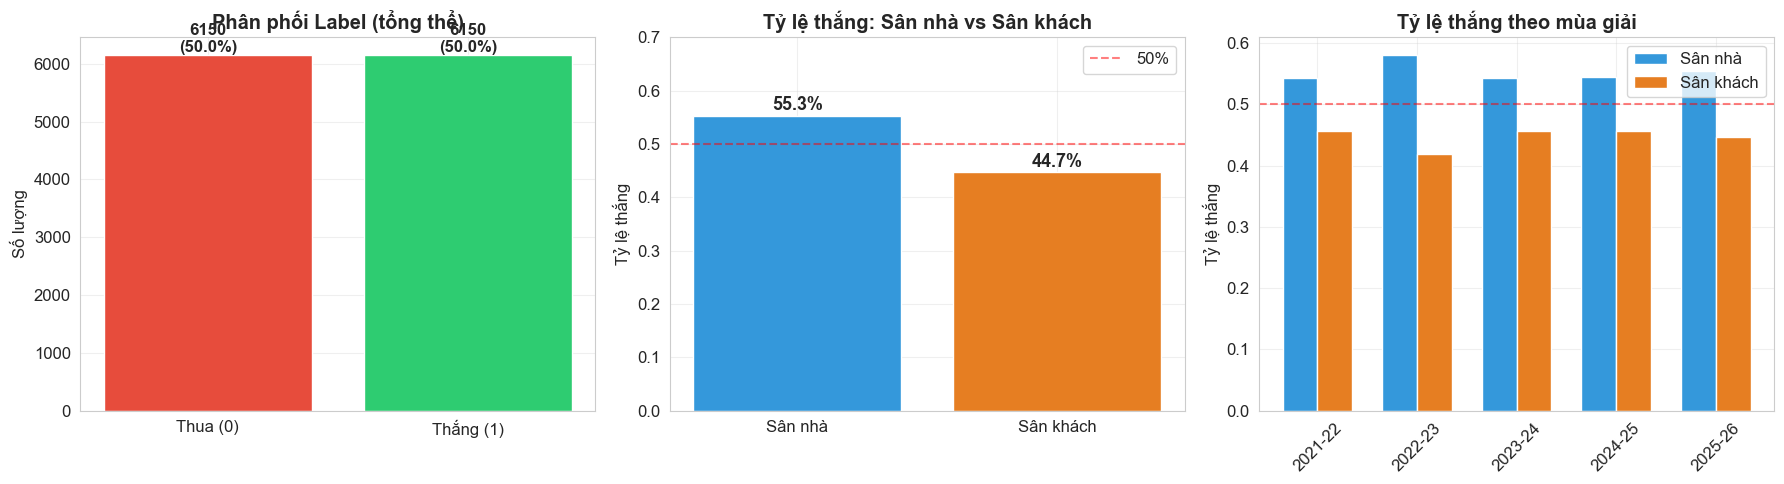


Lợi thế sân nhà: 55.3% vs 44.7% (chênh 10.6%)


In [5]:
# 2.1 — Phân phối Label + Home Court Advantage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Tổng thể
win_counts = df['WIN'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Thua (0)', 'Thắng (1)'], [win_counts[0], win_counts[1]], color=colors, edgecolor='white')
axes[0].set_title('Phân phối Label (tổng thể)', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate([win_counts[0], win_counts[1]]):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# (b) Sân nhà vs Sân khách
home_win = df[df['IS_HOME']==1]['WIN'].mean()
away_win = df[df['IS_HOME']==0]['WIN'].mean()
bars = axes[1].bar(['Sân nhà', 'Sân khách'], [home_win, away_win], color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Tỷ lệ thắng: Sân nhà vs Sân khách', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ thắng')
axes[1].set_ylim(0, 0.7)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()
for bar, val in zip(bars, [home_win, away_win]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.1%}', ha='center', fontweight='bold', fontsize=13)

# (c) Theo mùa giải
home_by_season = df[df['IS_HOME']==1].groupby('SEASON')['WIN'].mean()
away_by_season = df[df['IS_HOME']==0].groupby('SEASON')['WIN'].mean()
x = range(len(home_by_season))
width = 0.35
axes[2].bar([i - width/2 for i in x], home_by_season.values, width, label='Sân nhà', color='#3498db')
axes[2].bar([i + width/2 for i in x], away_by_season.values, width, label='Sân khách', color='#e67e22')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(home_by_season.index, rotation=45)
axes[2].set_title('Tỷ lệ thắng theo mùa giải', fontweight='bold')
axes[2].set_ylabel('Tỷ lệ thắng')
axes[2].legend()
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nba_data/eda_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLợi thế sân nhà: {home_win:.1%} vs {away_win:.1%} (chênh {home_win - away_win:.1%})")

### Nhận xét Phần 2
- **Label cân bằng hoàn hảo** (50/50) → Accuracy là metric phù hợp, không cần xử lý imbalanced data
- **Home court advantage có thật**: đội nhà thắng ~55% vs đội khách ~45% → `IS_HOME` là feature hữu ích
- Lợi thế sân nhà **ổn định qua các mùa** → pattern này đáng tin cậy

## 3. Phân phối các Feature chính (tách theo Thắng/Thua)

### 📌 Tại sao cần bước này?
Hiểu phân phối giúp ta quyết định:

1. **Feature nào phân biệt được thắng/thua?** → Nếu phân phối thắng và thua **tách biệt rõ** → feature mạnh. Nếu **chồng lên nhau hoàn toàn** → feature yếu, có thể loại bỏ.
2. **Có cần chuẩn hóa không?** → Logistic Regression, SVM nhạy cảm với scale (PTS ~113 vs FG_PCT ~0.47). Tree-based models thì không.
3. **Có outlier không?** → Ảnh hưởng đến linear models.

Ta dùng **Cohen's d** để đo mức chênh lệch giữa nhóm thắng/thua:
- |d| < 0.2: chênh lệch rất nhỏ → feature yếu
- 0.2 ≤ |d| < 0.5: chênh lệch vừa
- **|d| ≥ 0.5: chênh lệch đáng kể → feature tốt**
- |d| ≥ 0.8: chênh lệch lớn → feature rất mạnh

### Cohen's d là gì ?
- Là một thước đo effect size, dùng để đánh giá mức độ khác biệt giữa giá trị trung bình của hai nhóm. Nó đo lường khoảng cách giữa hai trung bình bằng đơn vị độ lệch chuẩn, giúp xác định ý nghĩa thực tiễn thay vì chỉ ý nghĩa thống kê
- Giả sử ta muốn biết: 'Đội thắng có ghi nhiều điểm hơn đội thua không?'. Cách đơn giản nhất là so sánh trung bình: đội thắng ghi trung bình 119 điểm, đội thua ghi 108 điểm (chênh 11 điểm). Nhưng con số 11 điểm này có đủ lớn hay không -> Ta cần một thước đo tính cả độ dao động (std)
```
Cohen's d = (Mean_thắng - Mean_thua) / Pooled_Std
```
- Ví dụ:
    - Giả sử ta có 6 trận, tách ra 2 nhóm: Nhóm thắng: PTS = [115, 120, 125] -> mean = 120, std = 5.0. Nhóm thua: PTS = [100, 108, 112] -> mean = 106.67,, std = 6.11
    - Pooled std là cách gộp độ dao động của 2 nhóm thành 1 con số
    ```
    Pooled_Std = √( (std_thắng² + std_thua²) / 2 )
           = √( (5.0² + 6.11²) / 2 )
           = √( (25 + 37.33) / 2 )
           = √( 31.17 )
           = 5.58
    ```
    - Tính Cohen's d:
    ```
    d = (mean_thắng - mean_thua) / pooled_std
    = (120 - 106.67) / 5.58
    = 13.33 / 5.58
    = 2.39
    ```

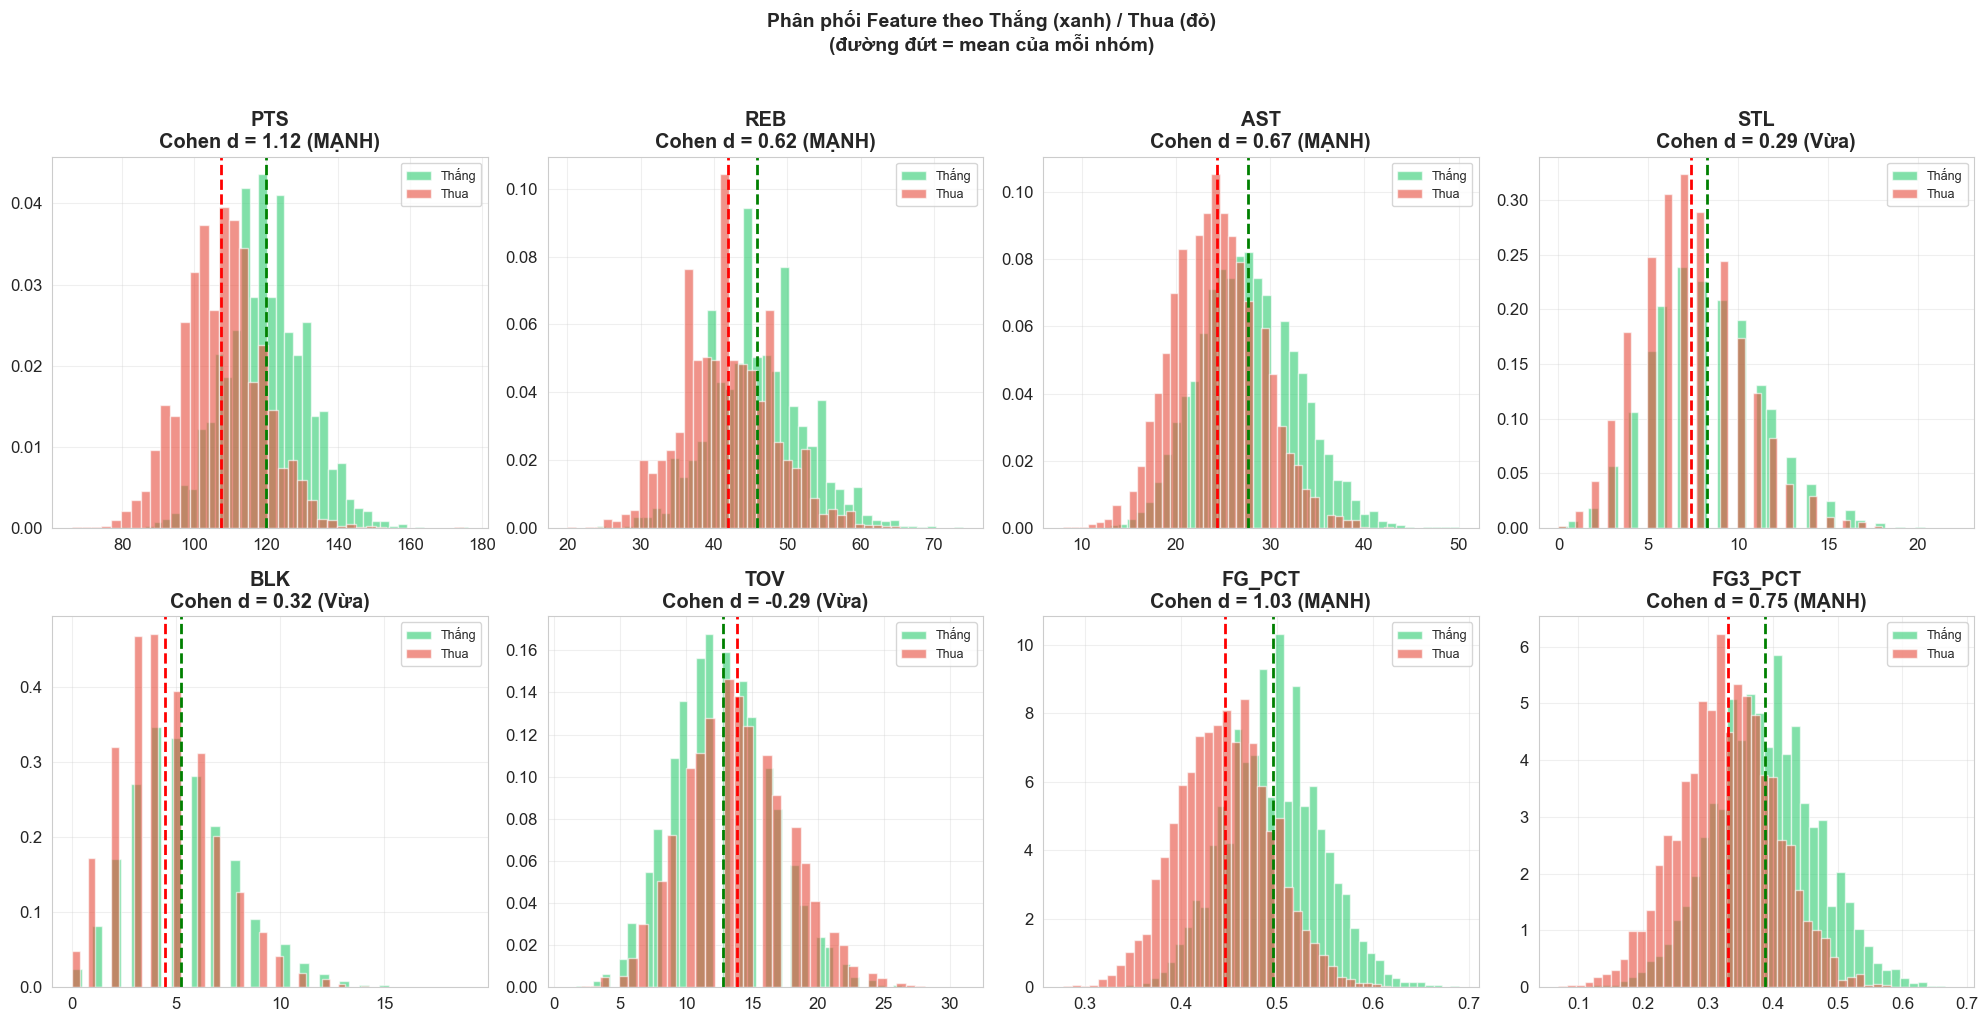


Tổng hợp Cohen's d (khả năng phân biệt Thắng/Thua):
---------------------------------------------
  PTS       : d = +1.119  🟢 MẠNH
  FG_PCT    : d = +1.031  🟢 MẠNH
  FG3_PCT   : d = +0.748  🟢 MẠNH
  AST       : d = +0.672  🟢 MẠNH
  REB       : d = +0.619  🟢 MẠNH
  BLK       : d = +0.317  🟡 Vừa
  STL       : d = +0.294  🟡 Vừa
  TOV       : d = -0.285  🟡 Vừa


In [6]:
# 3.1 — Histogram tách theo Thắng/Thua + Cohen's d
stat_features = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

cohen_d_results = {}

for i, col in enumerate(stat_features):
    win_data = df[df['WIN'] == 1][col]
    loss_data = df[df['WIN'] == 0][col]
    
    axes[i].hist(win_data, bins=40, alpha=0.6, color='#2ecc71', label='Thắng', density=True)
    axes[i].hist(loss_data, bins=40, alpha=0.6, color='#e74c3c', label='Thua', density=True)
    
    # Mean lines
    axes[i].axvline(win_data.mean(), color='green', linestyle='--', linewidth=2)
    axes[i].axvline(loss_data.mean(), color='red', linestyle='--', linewidth=2)
    
    # Cohen's d
    pooled_std = np.sqrt((win_data.std()**2 + loss_data.std()**2) / 2)
    d = (win_data.mean() - loss_data.mean()) / pooled_std
    cohen_d_results[col] = d
    
    strength = "MẠNH" if abs(d) >= 0.5 else ("Vừa" if abs(d) >= 0.2 else "Yếu")
    axes[i].set_title(f'{col}\nCohen d = {d:.2f} ({strength})', fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Phân phối Feature theo Thắng (xanh) / Thua (đỏ)\n(đường đứt = mean của mỗi nhóm)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nba_data/eda_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Tổng hợp Cohen's d
print("\nTổng hợp Cohen's d (khả năng phân biệt Thắng/Thua):")
print("-" * 45)
for col, d in sorted(cohen_d_results.items(), key=lambda x: abs(x[1]), reverse=True):
    strength = "🟢 MẠNH" if abs(d) >= 0.5 else ("🟡 Vừa" if abs(d) >= 0.2 else "🔴 Yếu")
    print(f"  {col:10s}: d = {d:+.3f}  {strength}")

### Nhận xét Phần 3
- **PTS và FG_PCT** có Cohen's d cao nhất → feature dự đoán mạnh nhất (đội thắng ghi nhiều điểm hơn và ném chính xác hơn — hợp lý!)
- **TOV** có d âm → đội thua mất bóng nhiều hơn
- **BLK, STL** có d nhỏ → khả năng dự đoán yếu khi dùng đơn lẻ

⚠️ Lưu ý: Những feature này là thống kê **của chính trận đó**. Khi dự đoán, ta không có dữ liệu này trước trận → sẽ cần dùng **rolling average** (trung bình N trận gần nhất) ở bước Feature Engineering.

## 4. Ma trận Tương quan (Correlation)

### 📌 Tại sao cần bước này?
Ma trận tương quan cho biết 2 điều quan trọng:

1. **Feature nào tương quan mạnh với WIN?** → Ưu tiên giữ lại cho mô hình
2. **Feature nào tương quan mạnh với nhau (multicollinearity)?** → Ví dụ: PTS và FGM tương quan rất cao (ghi điểm = ném rổ vào). Đưa cả 2 vào linear model sẽ gây bất ổn hệ số. Giải pháp: loại bớt 1 hoặc dùng tree-based model (ít bị ảnh hưởng)

Ngưỡng cần chú ý:
- **|r| > 0.7** giữa 2 features → multicollinearity cao
- **|r| > 0.3** với WIN → feature có tiềm năng

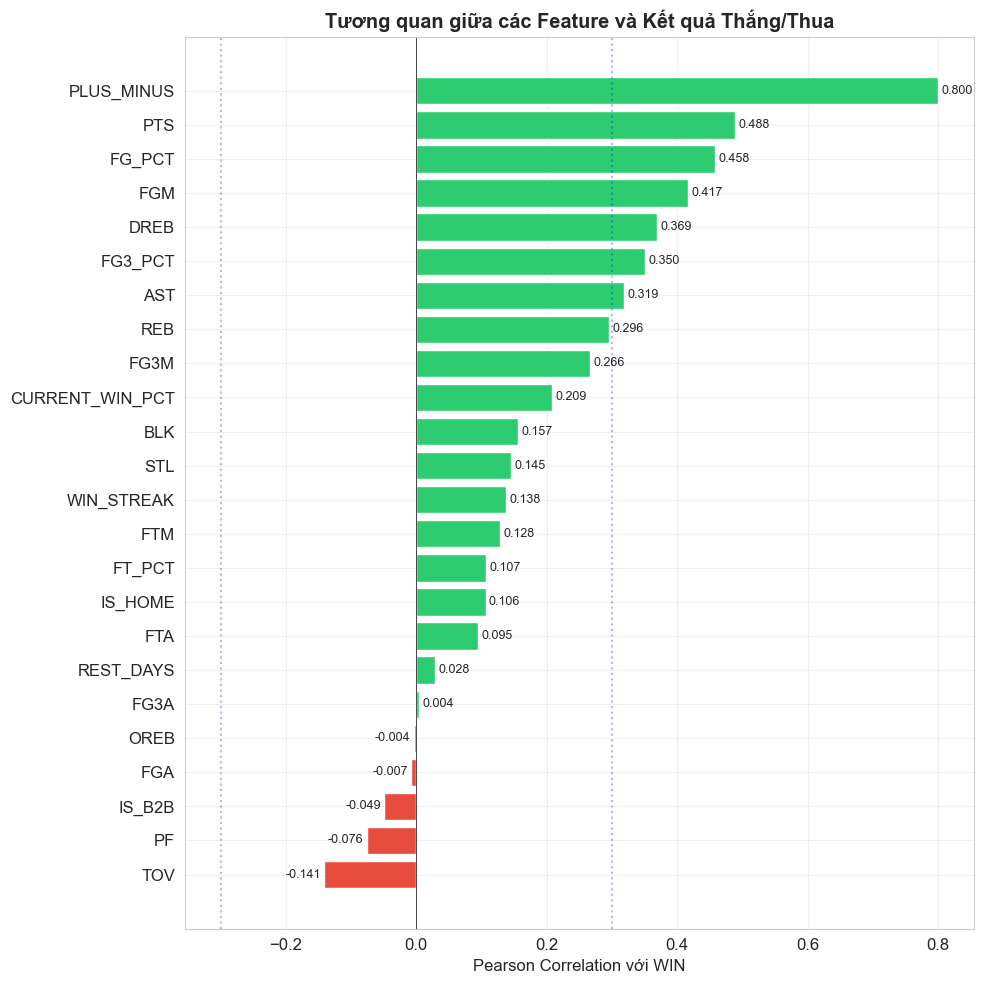

Top 5 feature tương quan DƯƠNG (giúp thắng):
  DREB                : +0.369
  FGM                 : +0.417
  FG_PCT              : +0.458
  PTS                 : +0.488
  PLUS_MINUS          : +0.800

Top 5 feature tương quan ÂM (dẫn đến thua):
  TOV                 : -0.141
  PF                  : -0.076
  IS_B2B              : -0.049
  FGA                 : -0.007
  OREB                : -0.004


In [7]:
# 4.1 — Tương quan với WIN
numeric_cols = ['PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
                'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
                'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS',
                'IS_HOME', 'REST_DAYS', 'IS_B2B', 'CURRENT_WIN_PCT', 'WIN_STREAK']

corr_with_win = df[numeric_cols + ['WIN']].corr()['WIN'].drop('WIN').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_win.values]
bars = ax.barh(corr_with_win.index, corr_with_win.values, color=colors, edgecolor='white')
ax.set_xlabel('Pearson Correlation với WIN')
ax.set_title('Tương quan giữa các Feature và Kết quả Thắng/Thua', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axvline(x=0.3, color='blue', linestyle=':', alpha=0.3, label='|r|=0.3')
ax.axvline(x=-0.3, color='blue', linestyle=':', alpha=0.3)

for bar, val in zip(bars, corr_with_win.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('nba_data/eda_03_correlation_with_win.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 feature tương quan DƯƠNG (giúp thắng):")
for feat, val in corr_with_win.tail(5).items():
    print(f"  {feat:20s}: {val:+.3f}")
print("\nTop 5 feature tương quan ÂM (dẫn đến thua):")
for feat, val in corr_with_win.head(5).items():
    print(f"  {feat:20s}: {val:+.3f}")

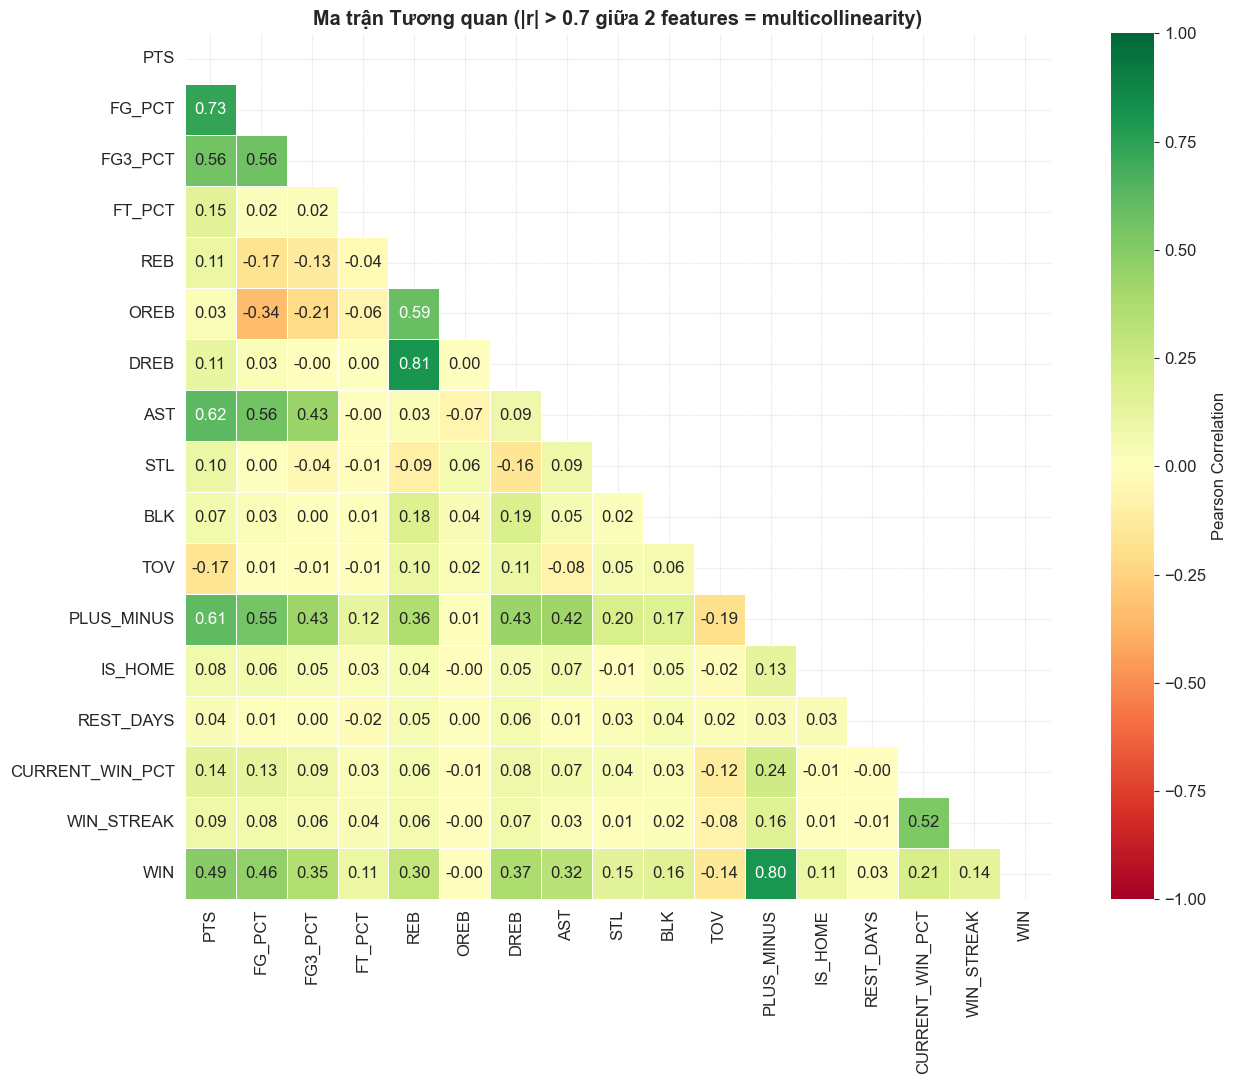

Các cặp feature có multicollinearity cao (|r| > 0.7):
  ⚠️ PTS             ↔ FG_PCT         : r = +0.732
  ⚠️ REB             ↔ DREB           : r = +0.808
  ⚠️ PLUS_MINUS      ↔ WIN            : r = +0.800


In [8]:
# 4.2 — Heatmap tương quan giữa các features (phát hiện multicollinearity)
key_features = ['PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'OREB', 'DREB',
                'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS',
                'IS_HOME', 'REST_DAYS', 'CURRENT_WIN_PCT', 'WIN_STREAK', 'WIN']

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Ma trận Tương quan (|r| > 0.7 giữa 2 features = multicollinearity)', fontweight='bold')

plt.tight_layout()
plt.savefig('nba_data/eda_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Cảnh báo multicollinearity
print("Các cặp feature có multicollinearity cao (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  ⚠️ {corr_matrix.columns[i]:15s} ↔ {corr_matrix.columns[j]:15s}: r = {r:+.3f}")

### Nhận xét Phần 4
- **PLUS_MINUS** tương quan cực mạnh với WIN → nhưng **KHÔNG ĐƯỢC DÙNG** vì đây là kết quả của trận, không phải input dự đoán (data leakage!)
    - **PLUS_MINUS** là chênh lệch điểm số cuối trận giữa đội đó và đối thủ. Ví dụ, ATL thắng DAL với tỷ số 113 - 87 -> **PLUS_MINUS** của ATL = +26, **PLUS_MINUS** của DAL = -26
    - Không được dùng feature này vì đây là data leakage: Nếu **PLUS_MINUS** > 0 -> chắc chắn WIN = 1. Nếu **PLUS_MINUS** < 0 -> Chắc chắn WIN = 0
- **FG_PCT, PTS, AST** là features tốt nhất (tương quan cao nhất sau PLUS_MINUS)
- **CURRENT_WIN_PCT, WIN_STREAK** (Nhóm 4) cũng có tương quan đáng kể → contextual features hữu ích
- **TOV, PF** tương quan âm → đội phạm lỗi nhiều và mất bóng nhiều dễ thua
- Cần cẩn thận với các cặp multicollinearity (PTS↔FGM, REB↔DREB,...) khi dùng linear models

### QUY TẮC CHUNG ĐỂ PHÁT HIỆN DATA LEAKAGE

- Trước khi đưa bất kỳ feature nào vào model, thì phải tự hỏi tại thời điểm trước trận đấu, ta có biết giá trị này không 
    - `IS_HOME`: Biết (Lịch thi đấu công khai)
    - `CURRENT_WIN_PCT`: Biết (tính từ các trận đã qua)
    - `REST_DAYS`: Biết (Lịch thi đấu)
    - `PTS`: Không biết (chưa đấu làm sao biết ghi bao nhiêu điểm)
    - `PLUS_MINUS`: Không biết (Chưa đấu làm sao biết chênh lệch)

- Ở bước Feature Engineering, tất cả thống kê trận đấu sẽ không dùng trực tiếp, mà phải chuyển thành rolling average (trung bình N trận gần nhất đã diễn ra trước đó). 
- PLUS_MINUS sẽ loại bỏ

## 5. Phân tích Contextual Features (Nhóm 4)

### 📌 Tại sao cần bước này?
Nhóm 4 là các feature ta **tự tạo** từ dữ liệu gốc. Cần kiểm chứng xem chúng có thực sự liên quan đến kết quả không:

- Nếu **có pattern rõ ràng** → feature tốt, giữ lại
- Nếu **không có pattern** → feature chỉ thêm noise, nên loại bỏ

Đây cũng là phần thú vị vì ta kiểm chứng được các "hiểu biết chung" về bóng rổ bằng dữ liệu:
- *"Đội back-to-back thường thua"* → Đúng hay sai?
- *"Momentum/hot hand có thật"* → Dữ liệu nói gì?

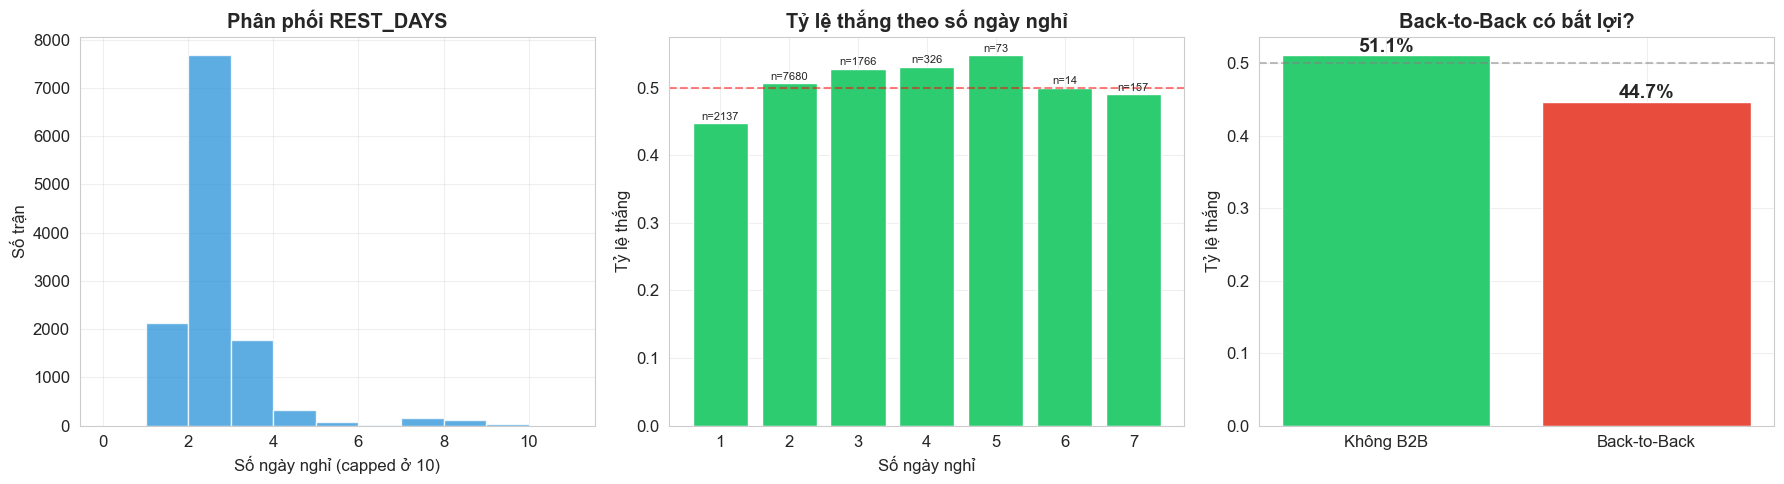

In [9]:
# 5.1 — REST_DAYS và Back-to-Back
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Phân phối REST_DAYS
rest_capped = df['REST_DAYS'].clip(upper=10)
axes[0].hist(rest_capped, bins=range(0, 12), color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Số ngày nghỉ (capped ở 10)')
axes[0].set_ylabel('Số trận')
axes[0].set_title('Phân phối REST_DAYS', fontweight='bold')

# (b) Tỷ lệ thắng theo REST_DAYS
rest_win = df[df['REST_DAYS'] <= 7].groupby('REST_DAYS')['WIN'].agg(['mean', 'count'])
bars = axes[1].bar(rest_win.index, rest_win['mean'], color='#2ecc71', edgecolor='white')
axes[1].set_xlabel('Số ngày nghỉ')
axes[1].set_ylabel('Tỷ lệ thắng')
axes[1].set_title('Tỷ lệ thắng theo số ngày nghỉ', fontweight='bold')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, rest_win.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'n={int(row["count"])}', ha='center', fontsize=8)

# (c) B2B vs Non-B2B
b2b_win = df.groupby('IS_B2B')['WIN'].mean()
bars = axes[2].bar(['Không B2B', 'Back-to-Back'], b2b_win.values, 
                    color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_ylabel('Tỷ lệ thắng')
axes[2].set_title('Back-to-Back có bất lợi?', fontweight='bold')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, b2b_win.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('nba_data/eda_05_rest_days.png', dpi=150, bbox_inches='tight')
plt.show()

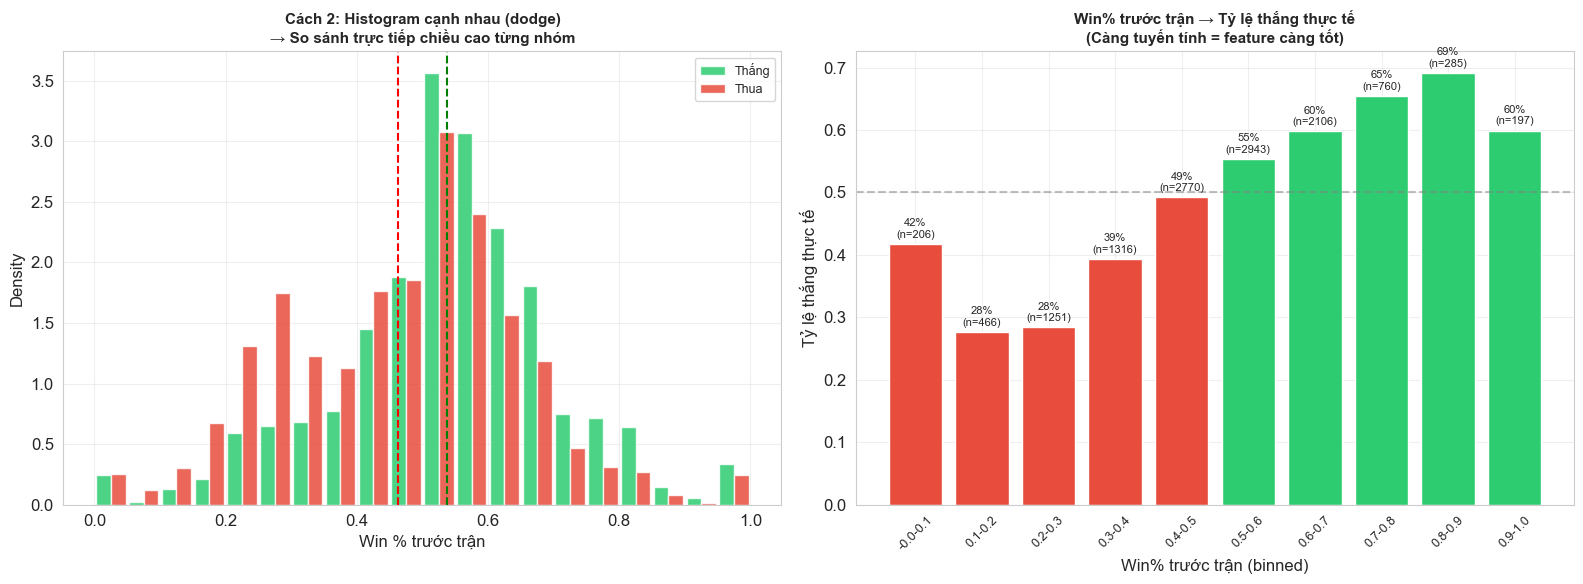

In [10]:
# =============================================================================
# 5.2 — CURRENT_WIN_PCT: Đội mạnh hơn có thắng nhiều hơn không? (Fixed)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

win_pct_w = df[df['WIN'] == 1]['CURRENT_WIN_PCT']
win_pct_l = df[df['WIN'] == 0]['CURRENT_WIN_PCT']


# ===== (b) Histogram KHÔNG chồng =====
bins = np.linspace(0, 1, 21)  # 20 bins
bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.45

counts_w, _ = np.histogram(win_pct_w, bins=bins)
counts_l, _ = np.histogram(win_pct_l, bins=bins)
counts_w_norm = counts_w / (len(win_pct_w) * (bins[1] - bins[0]))
counts_l_norm = counts_l / (len(win_pct_l) * (bins[1] - bins[0]))

axes[0].bar(bin_centers - width/2, counts_w_norm, width=width, color='#2ecc71', edgecolor='white', label='Thắng', alpha=0.85)
axes[0].bar(bin_centers + width/2, counts_l_norm, width=width, color='#e74c3c', edgecolor='white', label='Thua', alpha=0.85)
axes[0].axvline(win_pct_w.mean(), color='green', linestyle='--', linewidth=1.5)
axes[0].axvline(win_pct_l.mean(), color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Win % trước trận')
axes[0].set_ylabel('Density')
axes[0].set_title('Cách 2: Histogram cạnh nhau (dodge)\n→ So sánh trực tiếp chiều cao từng nhóm', fontweight='bold', fontsize=11)
axes[0].legend(fontsize=9)

# ===== (c) Binned Win Rate =====
df['_BIN'] = pd.cut(df['CURRENT_WIN_PCT'], bins=10)
bin_win = df.groupby('_BIN', observed=True)['WIN'].agg(['mean', 'count'])
bin_win = bin_win[bin_win['count'] > 50]

colors = ['#e74c3c' if v < 0.5 else '#2ecc71' for v in bin_win['mean']]
bars = axes[1].bar(range(len(bin_win)), bin_win['mean'], color=colors, edgecolor='white')
axes[1].set_xticks(range(len(bin_win)))
axes[1].set_xticklabels([f'{iv.left:.1f}-{iv.right:.1f}' for iv in bin_win.index], rotation=45, fontsize=9)
axes[1].set_xlabel('Win% trước trận (binned)')
axes[1].set_ylabel('Tỷ lệ thắng thực tế')
axes[1].set_title('Win% trước trận → Tỷ lệ thắng thực tế\n(Càng tuyến tính = feature càng tốt)', fontweight='bold', fontsize=11)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, bin_win.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=8)

df.drop(columns=['_BIN'], inplace=True)

plt.tight_layout()
plt.savefig('nba_data/eda_06_win_pct.png', dpi=150, bbox_inches='tight')
plt.show()


**TRÁI: Histogram tách theo Thắng / Thua**
- Nhìn vào vùng Win% cao, màu xanh nhiều hơn màu đỏ. Ngược lại ở vùng Win% thấp (0.1 - 0.3), màu đỏ chiếm đa số. 
- Đội có Win% cao trước trận thì thường thắng, đội thấp thì thường thua. Hai phân phối tách biệt nhau -> `CURRENT_WIN_PCT` là feature phân biệt tốt

**PHẢI: Binned Win Rate**
- Chia `CURRENT_WIN_PCT` thành 10 khoảng rồi tính tỷ lệ thắng thực tế trong mỗi khoảng. 
- Đội có Win% trước trận 0.0 - 0.1 thì tỷ lệ thắng thực tế chỉ ~ 42%. Đội có Win% 0.8-0.9 thì tỷ lệ thắng thực tế ~70%

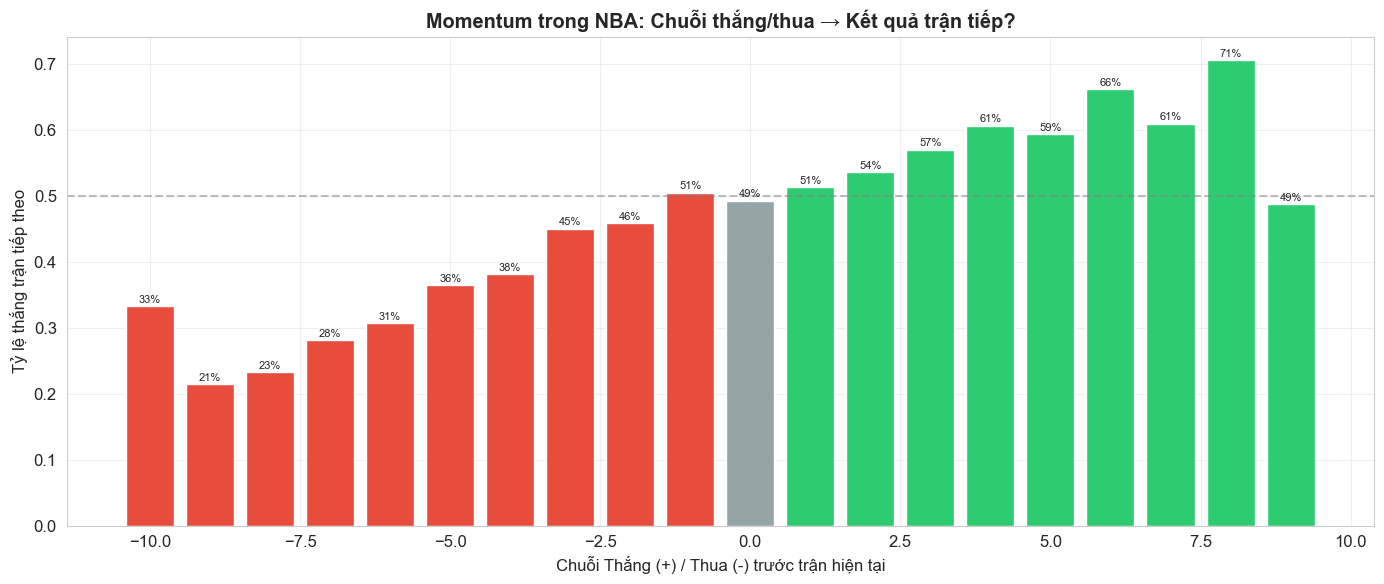

In [11]:
# 5.3 — WIN_STREAK: Momentum có thật không?
fig, ax = plt.subplots(figsize=(14, 6))

streak_data = df[(df['WIN_STREAK'] >= -10) & (df['WIN_STREAK'] <= 10)]
streak_win = streak_data.groupby('WIN_STREAK')['WIN'].agg(['mean', 'count'])
streak_win = streak_win[streak_win['count'] >= 30]

colors = ['#e74c3c' if idx < 0 else '#2ecc71' if idx > 0 else '#95a5a6' for idx in streak_win.index]
bars = ax.bar(streak_win.index, streak_win['mean'], color=colors, edgecolor='white')
ax.set_xlabel('Chuỗi Thắng (+) / Thua (-) trước trận hiện tại')
ax.set_ylabel('Tỷ lệ thắng trận tiếp theo')
ax.set_title('Momentum trong NBA: Chuỗi thắng/thua → Kết quả trận tiếp?', fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Ghi sample size
for bar, (idx, row) in zip(bars, streak_win.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["mean"]:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('nba_data/eda_07_momentum.png', dpi=150, bbox_inches='tight')
plt.show()

**Tại sao tới khúc 8,9 gì đó lại tụt**
- Sample size nhỏ: rất ít đội thắng 8 - 10 trận liên tiếp. Có thể ở streak +8 chỉ có vài chục trận trong toàn bộ dataset, trong khi streak +1 hoặc +2 có hàng nghìn trận. Khi sample size nhỏ, chỉ cần vài trận thua là tỷ lệ dao động rất mạnh. Ví dụ: nếu streak +8 chỉ có 30 trận mà 9 trận thua → tỷ lệ thắng chỉ còn 70%. Nhưng nếu có 1000 trận thì con số sẽ ổn định hơn nhiều.

### Nhận xét Phần 5
- **Back-to-back** ảnh hưởng tiêu cực → `IS_B2B` là feature hữu ích
- **CURRENT_WIN_PCT** có quan hệ gần tuyến tính với tỷ lệ thắng → feature rất mạnh (đội có win% cao thắng nhiều hơn thật)
- **WIN_STREAK** cho thấy momentum có thật: đội đang thắng liên tiếp có tỷ lệ thắng tiếp cao hơn → giữ feature này

## 6. Phân tích theo Thời gian

### 📌 Tại sao cần bước này?
Bài toán của ta là **dự đoán trận tiếp theo** → thời gian là yếu tố cốt lõi:

1. **Train/Test split phải theo thời gian**: dùng quá khứ dự đoán tương lai, KHÔNG random split (sẽ gây data leakage vì model "nhìn thấy" tương lai trong training)
2. **Phong độ đội thay đổi**: đội mạnh đầu mùa có thể yếu cuối mùa → cần rolling features
3. **Kiểm tra tính ổn định**: Nếu pattern (ví dụ home advantage) thay đổi nhiều theo thời gian → model khó generalize

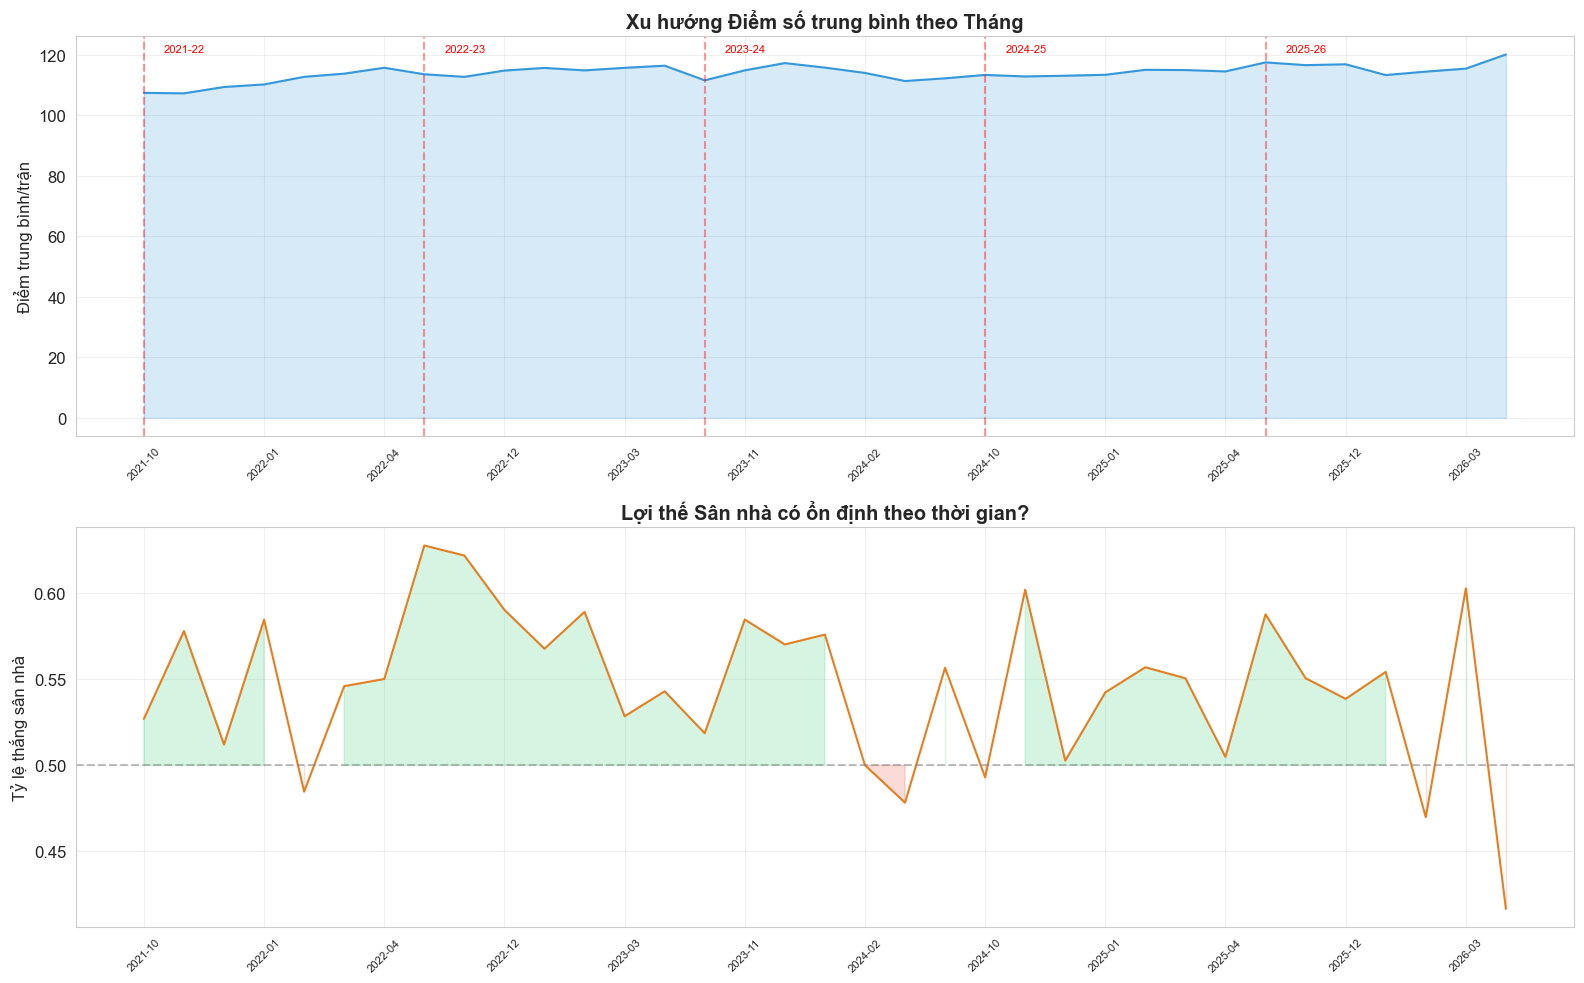

In [12]:
# 6.1 — Xu hướng theo thời gian
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

df['YEAR_MONTH'] = df['GAME_DATE'].dt.to_period('M')

# (a) Điểm trung bình theo tháng
monthly_pts = df.groupby('YEAR_MONTH')['PTS'].mean()
axes[0].plot(range(len(monthly_pts)), monthly_pts.values, color='#3498db', linewidth=1.5)
axes[0].fill_between(range(len(monthly_pts)), monthly_pts.values, alpha=0.2, color='#3498db')
axes[0].set_ylabel('Điểm trung bình/trận')
axes[0].set_title('Xu hướng Điểm số trung bình theo Tháng', fontweight='bold')

# Ranh giới mùa giải
season_starts = df.groupby('SEASON')['GAME_DATE'].min().dt.to_period('M')
for s, period in season_starts.items():
    if period in monthly_pts.index:
        idx = list(monthly_pts.index).index(period)
        axes[0].axvline(x=idx, color='red', linestyle='--', alpha=0.4)
        axes[0].text(idx+0.5, axes[0].get_ylim()[1]*0.98, s, fontsize=8, va='top', color='red')

tick_pos = range(0, len(monthly_pts), 3)
tick_labels = [str(monthly_pts.index[i]) for i in tick_pos if i < len(monthly_pts)]
axes[0].set_xticks(list(tick_pos)[:len(tick_labels)])
axes[0].set_xticklabels(tick_labels, rotation=45, fontsize=8)

# (b) Home advantage theo thời gian
monthly_home = df[df['IS_HOME']==1].groupby('YEAR_MONTH')['WIN'].mean()
axes[1].plot(range(len(monthly_home)), monthly_home.values, color='#e67e22', linewidth=1.5)
axes[1].fill_between(range(len(monthly_home)), 0.5, monthly_home.values, 
                      where=monthly_home.values > 0.5, alpha=0.2, color='#2ecc71')
axes[1].fill_between(range(len(monthly_home)), 0.5, monthly_home.values, 
                      where=monthly_home.values <= 0.5, alpha=0.2, color='#e74c3c')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Tỷ lệ thắng sân nhà')
axes[1].set_title('Lợi thế Sân nhà có ổn định theo thời gian?', fontweight='bold')
axes[1].set_xticks(list(tick_pos)[:len(tick_labels)])
axes[1].set_xticklabels(tick_labels, rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig('nba_data/eda_08_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['YEAR_MONTH'], inplace=True)

### ✅ Nhận xét Phần 6
- Điểm số trung bình có xu hướng **tăng nhẹ** qua các mùa → NBA ngày càng thiên về tấn công
- Lợi thế sân nhà **dao động** nhưng nhìn chung **ổn định trên 50%** → pattern đáng tin cậy
- Có **khoảng trống** giữa các mùa giải (off-season) → cần xử lý `REST_DAYS` cho trận đầu mùa

## 7. Phân tích theo Đội

### 📌 Tại sao cần bước này?
- **Kiểm tra dữ liệu đầy đủ**: 30 đội đều có đủ trận?
- **Sự chênh lệch sức mạnh**: đội top khác đội yếu bao nhiêu? → Ảnh hưởng đến tầm quan trọng của feature `CURRENT_WIN_PCT`
- **Phong cách chơi**: đội nào ghi nhiều điểm? đội nào phòng thủ tốt? → Insight cho feature engineering

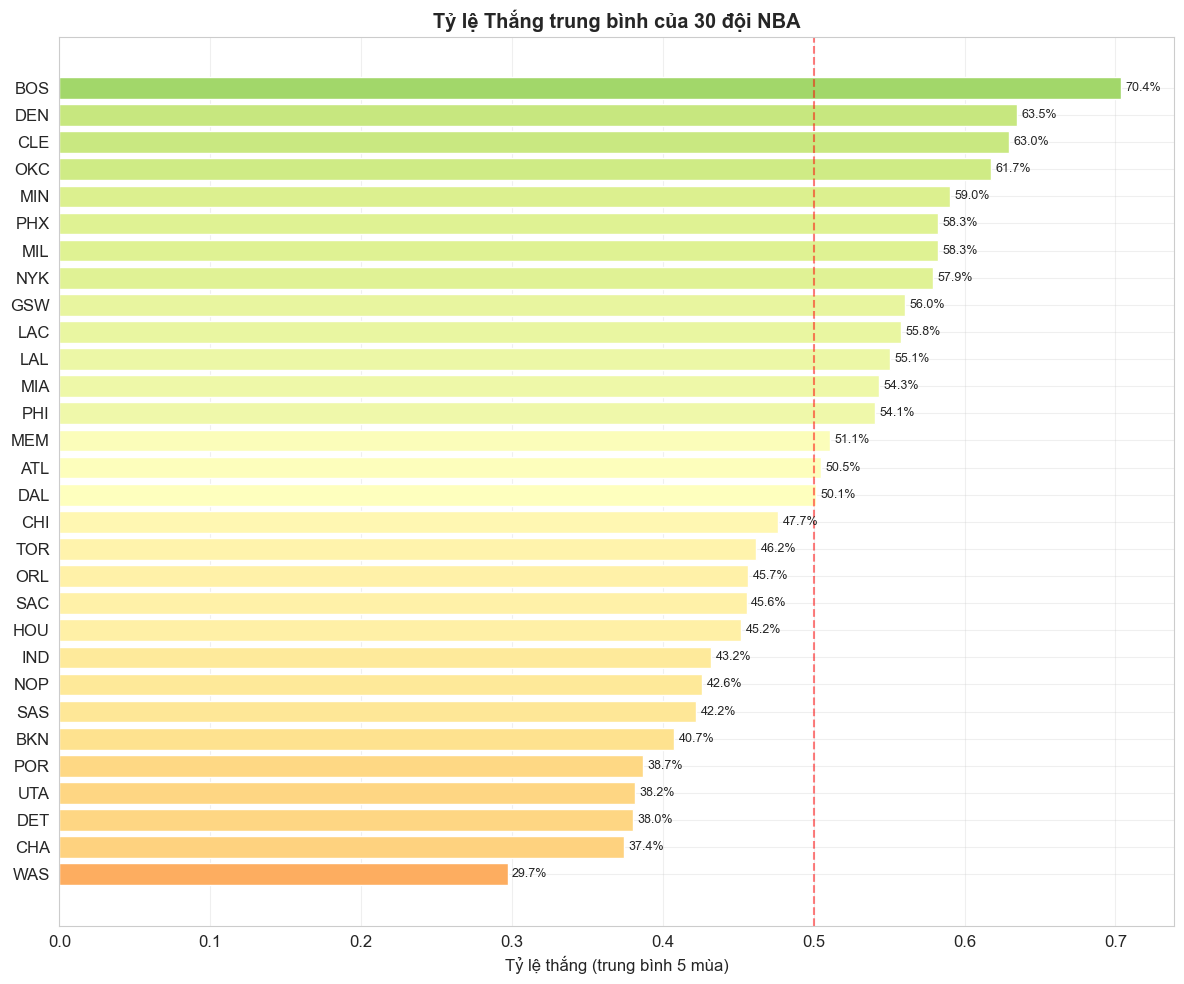

Số trận mỗi đội: min=404, max=406
Chênh lệch win rate: 70.4% (top) vs 29.7% (bottom)


In [13]:
# 7.1 — Tỷ lệ thắng tất cả đội
team_stats = df.groupby('TEAM_ABBREVIATION').agg(
    win_rate=('WIN', 'mean'),
    avg_pts=('PTS', 'mean'),
    avg_ast=('AST', 'mean'),
    avg_reb=('REB', 'mean'),
    avg_tov=('TOV', 'mean'),
    games=('GAME_ID', 'nunique')
).sort_values('win_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.RdYlGn(team_stats['win_rate'].values)
bars = ax.barh(team_stats.index, team_stats['win_rate'], color=colors, edgecolor='white')
ax.set_xlabel('Tỷ lệ thắng (trung bình 5 mùa)')
ax.set_title('Tỷ lệ Thắng trung bình của 30 đội NBA', fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

for bar, val in zip(bars, team_stats['win_rate']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nba_data/eda_09_team_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Số trận mỗi đội: min={team_stats['games'].min()}, max={team_stats['games'].max()}")
print(f"Chênh lệch win rate: {team_stats['win_rate'].max():.1%} (top) vs {team_stats['win_rate'].min():.1%} (bottom)")

# 1. TẠI SAO LẠI DÙNG ROLLING FEATURES THAY VÌ RAW FEATURES ?



- Vấn đề: Các thống kê trận đấu (PTS, AST, FG_PCT...) là kết quả sau trận - tại thời điểm trước trận, ta không biết đội sẽ ghi bao nhiêu điểm. Nếu dùng trực tiếp -> data leakage
- Bổ sung khái niệm "Nhiễu" (Noise) và "Phong độ" (Momentum/Form): Bạn có thể giải thích thêm rằng trong bóng rổ, một trận đấu xuất thần (ghi 140 điểm) hoặc ném rất tệ (FG_PCT < 30%) chỉ là các "nhiễu" ngẫu nhiên (outliers) do thể lực hoặc cảm giác bóng ngày hôm đó. Việc tính trung bình trượt (rolling average) có tác dụng "làm mịn" (smoothing) dữ liệu, loại bỏ nhiễu để bộc lộ rõ phong độ thực sự của đội bóng.
- Minh chứng từ paper: Horvat el at. (2023) chỉ ra rằng khi dùng raw data trực tiếp + ML classifiers, accuracy chỉ đạt ~ 55.8% (Bảng 5 trong paper). Đây gần như không khác gì tung đồng xu (50%). Lý do: raw stats của 1 trận đơn lẻ quá nhiều, không phản ánh được sức mạnh thực sự của đội
- Giải pháp: Tính trung bình trượt N trận gần nhất (rolling average) với `shift(1)` để chỉ dùng dữ liệu trước trận hiện tại. 
- Kiểm chứng từ EDA: Phần 9 tổng kết EDA ghi rõ: 'PTS, FG_PCT có Cohen's d cao -> features mạnh nhất - nhưng cần dùng dạng rolling average'

**Gợi ý chuyển ngữ thành văn báo cáo**
- Trong các bài toán dự đoán thể thao, việc sử dụng trực tiếp các thống kê nguyên bản (Raw Features) như điểm số (PTS) hay Tỷ lệ ném rổ (FG_PCT) của chính trận đấu mục tiêu sẽ dẫn đến sai lầm nghiêm trọng về rò rỉ dữ liệu tương lai. Thực nghiệm từ nghiên cứu của `Horvat et al. (2023)` đã chỉ ra rằng, khi sử dụng raw data kết hợp với các thuật toán phân loại ML, độ chính xác chỉ khoảng 55.8% (Bảng 5)

- Trả lời cho câu hỏi: 'Tại sao không đưa thẳng dữ liệu cào được vào chạy model cho nhanh ?'


# 2. TẠI SAO TẠO DIFFERENCE FEATURES ?
- Minh chứng từ paper Horvat: Paper đề xuất chỉ số ICMPR (Comparative Index) - tính bằng hiệu giữa chỉ số đội nhà và đội khách. Kết quả: Khi kết hợp IBASIC + ICMPR, accuracy tăng. 
- Minh chứng từ paper Migliorati: Phân tích 19,138 trận NBA cho thấy diff index (chênh lệch win% giữa 2 đội) là yếu tố phân biệt quan trọng nhất giữa các loại trận đấu. Threshold phân hoạch âm (~-0.19 đến -0.24) xác nhận đội nhà được "bonus" → chênh lệch giữa 2 đội mang thông tin dự đoán mạnh.

# 3. Quyết định dùng EMA 

- Trong thực tế nó là vậy, phong độ sẽ phụ thuộc rất nhiều vào trận gần nhất, trận càng lâu phụ thuộc càng ít


In [13]:
for i in range(len(df.columns)):
    print(df.columns[i])
print(len(df.columns))

SEASON_ID
TEAM_ID
TEAM_ABBREVIATION
TEAM_NAME
GAME_ID
GAME_DATE
MATCHUP
WL
MIN
PTS
FGM
FGA
FG_PCT
FG3M
FG3A
FG3_PCT
FTM
FTA
FT_PCT
OREB
DREB
REB
AST
STL
BLK
TOV
PF
PLUS_MINUS
SEASON
IS_HOME
WIN
REST_DAYS
IS_B2B
GAMES_PLAYED_SEASON
CURRENT_WIN_PCT
WIN_STREAK
36


### TỔNG HỢP FEATURE ENGINEERING V1

**1. Xử lý issues từ EDA**
- Fill `FT_PCT` NaN = 0
- Cap `REST_DAYS` ở 10 ngày
- Loại các trận neural site (cả 2 đội IS_HOME = 0)

**2. Tính EMA (span = 5) cho 10 features**

`PTS, FG_PCT, FG3_PCT, FT_PCT, OREB, DREB, AST, STL, BLK, TOV`
- Dùng shift(1) để tránh data leakage. Kết quả tạo ra 10 cột mới: `EMA_PTS, EMA_FG_PCT, EMA_FG3_PCT, EMA_FT_PCT, EMA_OREB, EMA_DREB, EMA_AST, EMA_STL, EMA_BLK, EMA_TOV.`

**3. Ghép 2 đội thành 1 dòng/trận**
- Tách HOME và AWAY, merge theo GAME_ID. Mỗi dòng = 1 trận, có cột HOME_EMA_PTS, AWAY_EMA_PTS, HOME_CURRENT_WIN_PCT, AWAY_CURRENT_WIN_PCT....

**4. Tạo Difference Features (HOME - AWAY)**
- 13 features chênh lệch:
    - 10 từ EMA: `DIFF_PTS, DIFF_FG_PCT, DIFF_FG3_PCT, DIFF_FT_PCT, DIFF_OREB, DIFF_DREB, DIFF_AST, DIFF_STL, DIFF_BLK, DIFF_TOV`
    - 3 từ contextual: `DIFF_WIN_PCT, DIFF_WIN_STREAK, DIFF_REST_DAYS`

**5. Xác định bộ features đưa vào model train**
- Bộ features gồm 15 cột: 13 DIFF features + `HOME_IS_B2B` + `AWAY_IS_B2B`
- Các features bị loại, không đưa vào model:
    - `PLUS_MINUS` - data leakage (r = 0.799 với WIN)
    - Tất cả raw stats gốc: `PTS, FGM, FGA, FG_PCT, FG3M, FG3A, FG3_PCT, FTM, FTA, FT_PCT, OREB, DREB, REB, AST, STL, BLK, TOV, PF, MIN` - vì đây là kết quả sau trận, ta chỉ dùng chúng để tính EMA rồi bỏ
    - `FGM` - không tính EMA vì thừa với PTS
    - `REB` - không tính EMA vì thừa với OREB + DREB
    - `PF` - không tính rebound vì tương quan với WIN quá yếu
    - `FGA, FG3A, FTA` - không tính EMA vì đã encode trong FG_PCT, FG3_PCT, FT_PCT
    - Các cột metadata: `SEASON_ID, TEAM_ID, TEAM_ABBREVIATION, TEAM_NAME, GAME_ID, GAME_DATE, MATCHUP, WL, WIN, SEASON`

- Label: `HOME_WIN` (1 = đội nhà thắng, 0 = đội khách thắng)

**6. Train/Test split theo thời gian**
